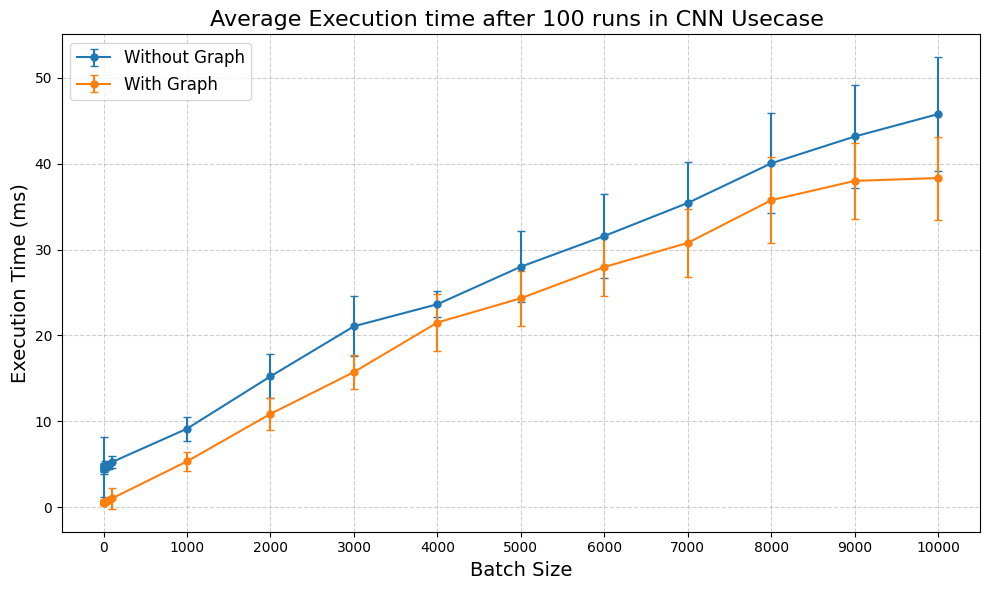

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read your two files
df_no_graph = pd.read_csv("Batch.csv")
df_with_graph = pd.read_csv("BatchGraph.csv")

# Group by BatchSize and calculate mean and std
stats_no_graph = df_no_graph.groupby("BatchSize")["ExecutionTime(ms)"].agg(["mean", "std"]).reset_index()
stats_with_graph = df_with_graph.groupby("BatchSize")["ExecutionTime(ms)"].agg(["mean", "std"]).reset_index()

# Plot
plt.figure(figsize=(10,6))

plt.errorbar(stats_no_graph["BatchSize"], stats_no_graph["mean"], 
             yerr=stats_no_graph["std"], fmt='-o', capsize=3, markersize=5, label="Without Graph")

plt.errorbar(stats_with_graph["BatchSize"], stats_with_graph["mean"], 
             yerr=stats_with_graph["std"], fmt='-o', capsize=3, markersize=5, label="With Graph")

plt.title("Average Execution time after 100 runs in CNN Usecase ", fontsize=16)
plt.xlabel("Batch Size", fontsize=14)
plt.ylabel("Execution Time (ms)", fontsize=14)
# plt.xticks(stats_no_graph["BatchSize"])  # ensures all batch sizes are shown
plt.xticks([0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000])

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [16]:
import os
import time
import torch
from torchvision import models
from PIL import Image

model_selectors = [
    "squeezenet1_1",
    "mobilenet_v2",
    "resnet18",
    "vgg16",
]

model_registry = {
    "squeezenet1_1": (models.squeezenet1_1, models.SqueezeNet1_1_Weights.DEFAULT),
    "mobilenet_v2": (models.mobilenet_v2, models.MobileNet_V2_Weights.DEFAULT),
    "resnet18": (models.resnet18, models.ResNet18_Weights.DEFAULT),
    "vgg16": (models.vgg16, models.VGG16_Weights.DEFAULT),
}

device = "cuda" 
# device="cpu"

img_dir = "imagenet_test_1000"
input_shape = (1, 3, 224, 224)   
dtype = torch.float32 

for model_selector in model_selectors:
    if model_selector not in model_registry:
        print(f"Model '{model_selector}' is not supported, skipping.")
        continue

    model_fn, weights = model_registry[model_selector]

    if model_selector == "inception_v3":
        model = model_fn(weights=weights, aux_logits=False)
    else:
        model = model_fn(weights=weights)


    model = model.to(device)
    model.eval()

    preprocess = weights.transforms()

    time_log_file = f"time_{model_selector}_{device}_graph.txt"

    correct = 0
    total = 0

    Warmup = 10
    s = torch.cuda.Stream()
    s.wait_stream(torch.cuda.current_stream())

    # allocate without touching RNG
    static_input = torch.empty(input_shape, device=device, dtype=dtype)
    path = os.path.join(img_dir, next(fn for fn in os.listdir(img_dir)
                                                if fn.lower().endswith(('.jpg','.jpeg','.png'))))
    true_label = int(path.split("/")[1].split("_")[0])
    print(true_label)
    # fill with a representative real sample (also avoids data-dependent kernel changes later)
    img0 = Image.open(path).convert("RGB")
    rep = preprocess(img0).unsqueeze(0).to(device, non_blocking=True)
    static_input.copy_(rep)

    for i in range(Warmup):
        with torch.cuda.stream(s):
            with torch.no_grad():
                static_output = model(static_input)
        torch.cuda.current_stream().wait_stream(s)
    g = torch.cuda.CUDAGraph()
    g.enable_debug_mode() 
    with torch.cuda.graph(g):
        static_output = model(static_input)
    g.replay()
    _, predicted_idx = torch.max(static_output, 1)
    predicted_label = predicted_idx.item()
    print(predicted_label)
    dot_path = f"{model_selector}_cuda_graph.dot"
    g.debug_dump(dot_path)
    print("DOT saved to:", dot_path, "exists?", os.path.exists(dot_path))

392


[W918 13:24:27.886478835 CUDAGraph.cpp:307] Warning: CUDA warning: invalid argument (function reset)
/usr/local/lib/python3.8/dist-packages/torch/cuda/graphs.py:113: UserWarning: DEBUG: calling cudaGraphDebugDotPrint() with squeezenet1_1_cuda_graph.dot (Triggered internally at ../aten/src/ATen/cuda/CUDAGraph.cpp:270.)
  return super().debug_dump(debug_path)


392
DOT saved to: squeezenet1_1_cuda_graph.dot exists? True
392


[W918 13:24:27.271770802 CUDAGraph.cpp:307] Warning: CUDA warning: invalid argument (function reset)
/usr/local/lib/python3.8/dist-packages/torch/cuda/graphs.py:113: UserWarning: DEBUG: calling cudaGraphDebugDotPrint() with mobilenet_v2_cuda_graph.dot (Triggered internally at ../aten/src/ATen/cuda/CUDAGraph.cpp:270.)
  return super().debug_dump(debug_path)


392
DOT saved to: mobilenet_v2_cuda_graph.dot exists? True
392


[W918 13:24:28.747976922 CUDAGraph.cpp:307] Warning: CUDA warning: invalid argument (function reset)


392
DOT saved to: resnet18_cuda_graph.dot exists? True
392


[W918 13:24:30.688741991 CUDAGraph.cpp:307] Warning: CUDA warning: invalid argument (function reset)


392
DOT saved to: vgg16_cuda_graph.dot exists? True
